In [5]:
import os

print(os.listdir('/content'))

['.config', 'sample superstore db.csv', 'sample_data']


In [6]:
import pandas as pd

df = pd.read_csv('/content/sample superstore db.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [7]:
df.shape

(10194, 21)

In [8]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [10]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
# Convert Date Columns

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [16]:
# Create New Time Features

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month_name()
df['Month_Number'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

In [17]:
df[['Order Date','Year','Month','Month_Number','Quarter']].head()

,Order Date,Year,Month,Month_Number,Quarter
0,2023-01-03,2023,January,1,1
1,2023-01-04,2023,January,1,1
2,2023-01-04,2023,January,1,1
3,2023-01-04,2023,January,1,1
4,2023-01-05,2023,January,1,1


In [18]:
df[['Year','Month','Quarter']].describe(include='all')

,Year,Month,Quarter
count,10194.000000,10194,10194.000000
unique,NaN,12,NaN
top,NaN,November,NaN
freq,NaN,1474,NaN
mean,2024.720129,NaN,2.882676
std,1.125611,NaN,1.060316
min,2023.000000,NaN,1.000000
25%,2024.000000,NaN,2.000000
50%,2025.000000,NaN,3.000000
75%,2026.000000,NaN,4.000000


In [19]:
print("Years :", df['Year'].unique())

print("\nMonths :")

print(df['Month'].unique())

print("\nQuarters :")

print(df['Quarter'].unique())

Years : [2023 2024 2025 2026]

Months :
['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August'
 'September' 'October' 'November' 'December']

Quarters :
[1 2 3 4]


In [20]:
print("Total Sales : $", round(df['Sales'].sum(),2))

Total Sales : $ 2326534.35


In [21]:
print("Total Profit : $", round(df['Profit'].sum(),2))

Total Profit : $ 292296.81


In [22]:
print("Total Orders :", df['Order ID'].nunique())

Total Orders : 5111


In [23]:
print("Total Customers :", df['Customer ID'].nunique())

Total Customers : 804


In [24]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

,Sales
Category,
Technology,839893.2790
Furniture,754747.7613
Office Supplies,731893.3140


In [25]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,739813.6085
East,691828.1680
Central,503170.6728
South,391721.9050


In [26]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

,Sales
Region,
West,739813.6085
East,691828.1680
Central,503170.6728
South,391721.9050


In [27]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

region_profit

,Profit
Region,
West,110798.8170
East,94883.2603
South,46749.4303
Central,39865.3070


In [28]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

,Sales
Segment,
Consumer,1.170660e+06
Corporate,7.158061e+05
Home Office,4.400684e+05


In [29]:
monthly_sales = df.groupby('Month_Number')['Sales'].sum()

monthly_sales

,Sales
Month_Number,
1,96069.5156
2,59751.2514
3,210672.0868
4,138098.7486
5,158765.0337
6,153459.9973
7,149001.7130
8,161821.9150
9,308883.6697


In [30]:
yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

,Sales
Year,
2023,494040.2121
2024,472993.0310
2025,613933.5800
2026,745567.5312


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

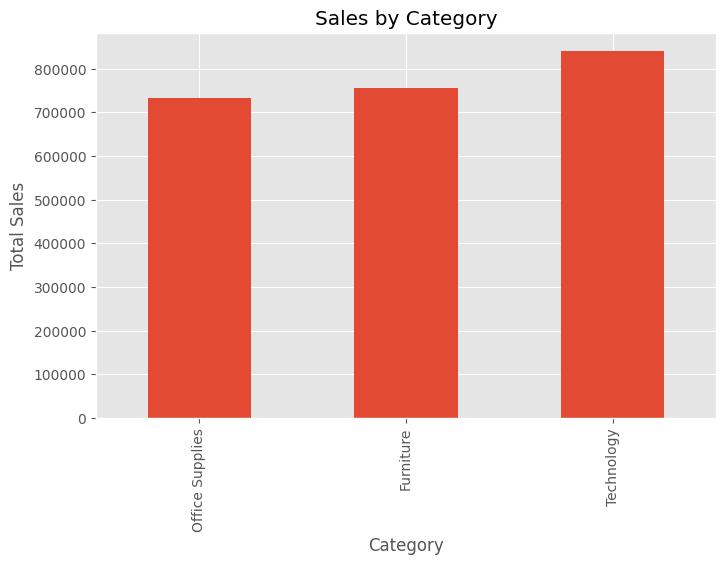

In [32]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Sales'].sum().sort_values().plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

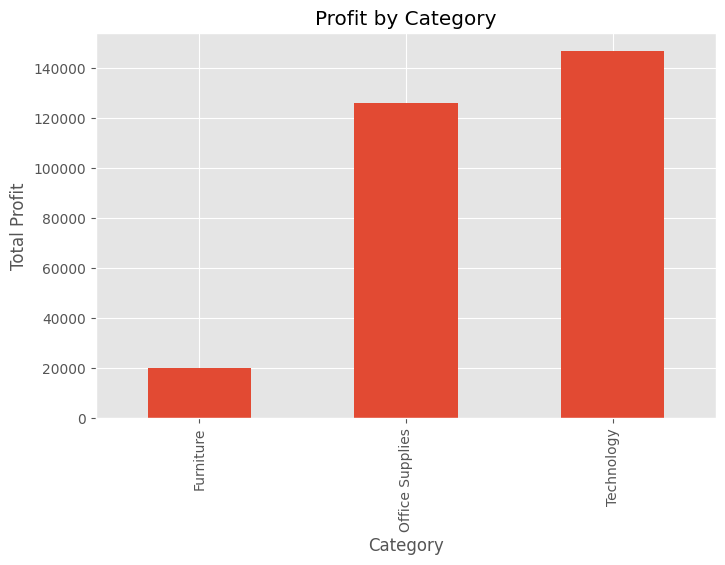

In [33]:
plt.figure(figsize=(8,5))

df.groupby('Category')['Profit'].sum().sort_values().plot(kind='bar')

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

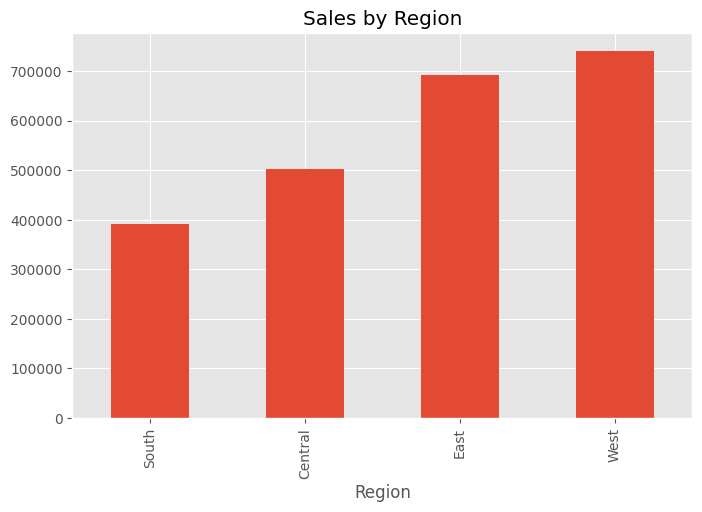

In [34]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Sales'].sum().sort_values().plot(kind='bar')

plt.title("Sales by Region")

plt.show()

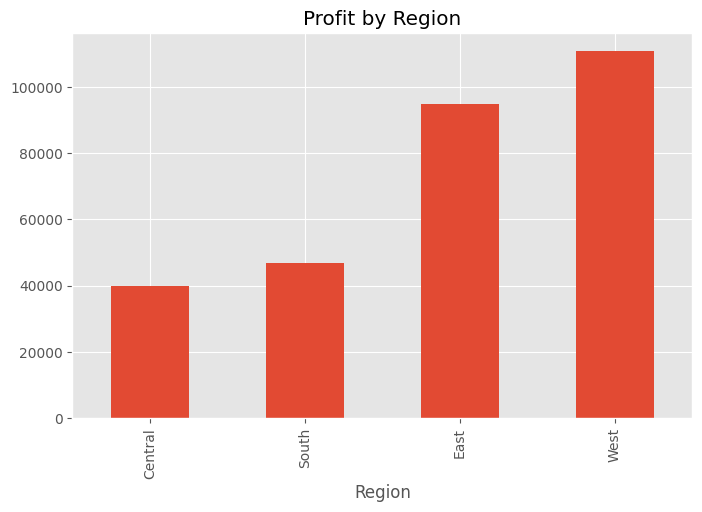

In [35]:
plt.figure(figsize=(8,5))

df.groupby('Region')['Profit'].sum().sort_values().plot(kind='bar')

plt.title("Profit by Region")

plt.show()

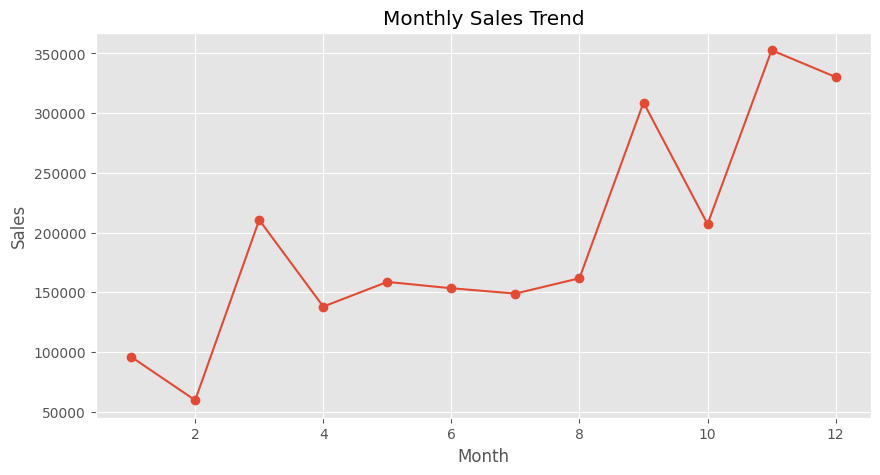

In [36]:
monthly_sales = df.groupby('Month_Number')['Sales'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

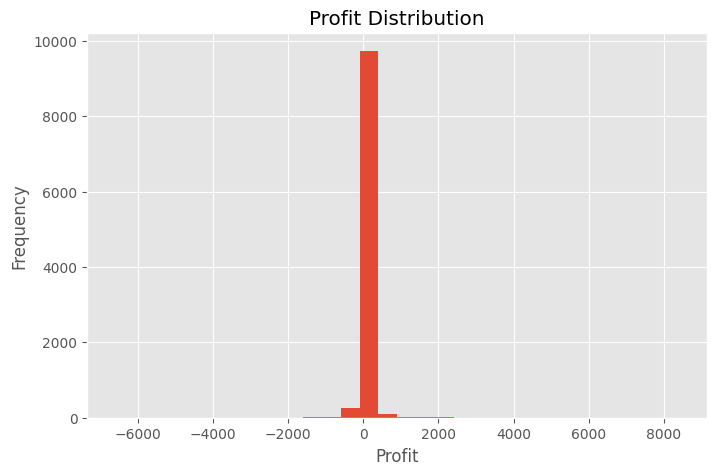

In [37]:
plt.figure(figsize=(8,5))

plt.hist(df['Profit'], bins=30)

plt.title("Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()

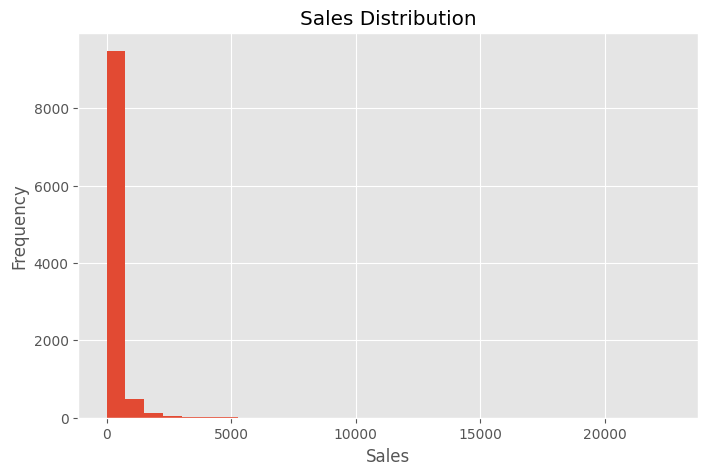

In [38]:
plt.figure(figsize=(8,5))

plt.hist(df['Sales'], bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

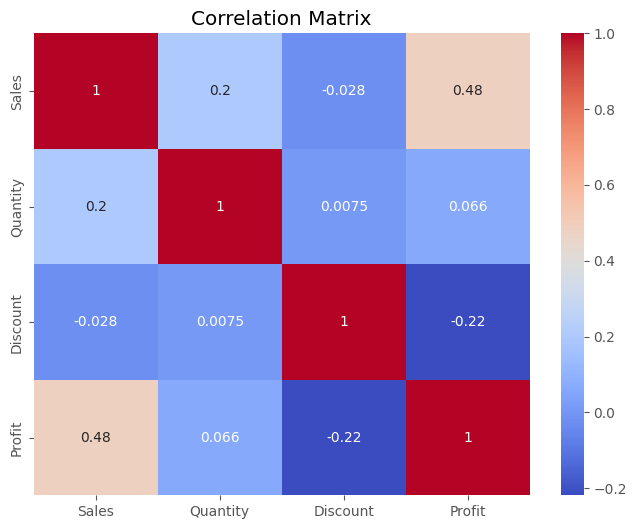

In [39]:
numeric_df = df[['Sales','Quantity','Discount','Profit']]

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

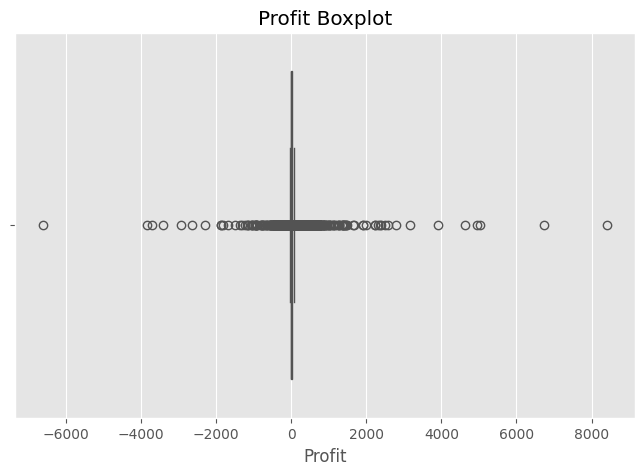

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Profit'])

plt.title("Profit Boxplot")

plt.show()

In [41]:
print("========== BUSINESS INSIGHTS ==========")

print("1. Technology category generated the highest sales.")

print("2. Technology category produced the highest profit.")

print("3. West region achieved the highest sales.")

print("4. West region generated the highest overall profit.")

print("5. Monthly sales increased significantly toward the end of the year.")

print("6. Discount has a negative impact on Profit.")

print("7. Sales and Profit are moderately positively correlated.")

print("8. No missing values were found in the dataset.")

print("9. No duplicate records were found.")

print("10. Dataset is clean and ready for business analysis.")

========== BUSINESS INSIGHTS ==========
1. Technology category generated the highest sales.
2. Technology category produced the highest profit.
3. West region achieved the highest sales.
4. West region generated the highest overall profit.
5. Monthly sales increased significantly toward the end of the year.
6. Discount has a negative impact on Profit.
7. Sales and Profit are moderately positively correlated.
8. No missing values were found in the dataset.
9. No duplicate records were found.
10. Dataset is clean and ready for business analysis.


In [42]:
summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Total Sales": round(df["Sales"].sum(),2),
    "Total Profit": round(df["Profit"].sum(),2),
    "Average Sales": round(df["Sales"].mean(),2),
    "Average Profit": round(df["Profit"].mean(),2)
}

for k,v in summary.items():
    print(f"{k}: {v}")

Rows: 10194
Columns: 25
Missing Values: 0
Duplicate Rows: 0
Total Sales: 2326534.35
Total Profit: 292296.81
Average Sales: 228.23
Average Profit: 28.67


In [43]:
print("="*60)
print(" Retail Business Performance Analysis Completed Successfully ")
print("="*60)

print("\nProject Includes:")

print("✔ Data Loading")
print("✔ Data Cleaning")
print("✔ Data Type Conversion")
print("✔ Feature Engineering")
print("✔ Exploratory Data Analysis")
print("✔ Data Visualization")
print("✔ Business Insights")
print("✔ Summary Report")

print("\nPrepared by: Papai Ghosh")

 Retail Business Performance Analysis Completed Successfully 

Project Includes:
✔ Data Loading
✔ Data Cleaning
✔ Data Type Conversion
✔ Feature Engineering
✔ Exploratory Data Analysis
✔ Data Visualization
✔ Business Insights
✔ Summary Report

Prepared by: Papai Ghosh


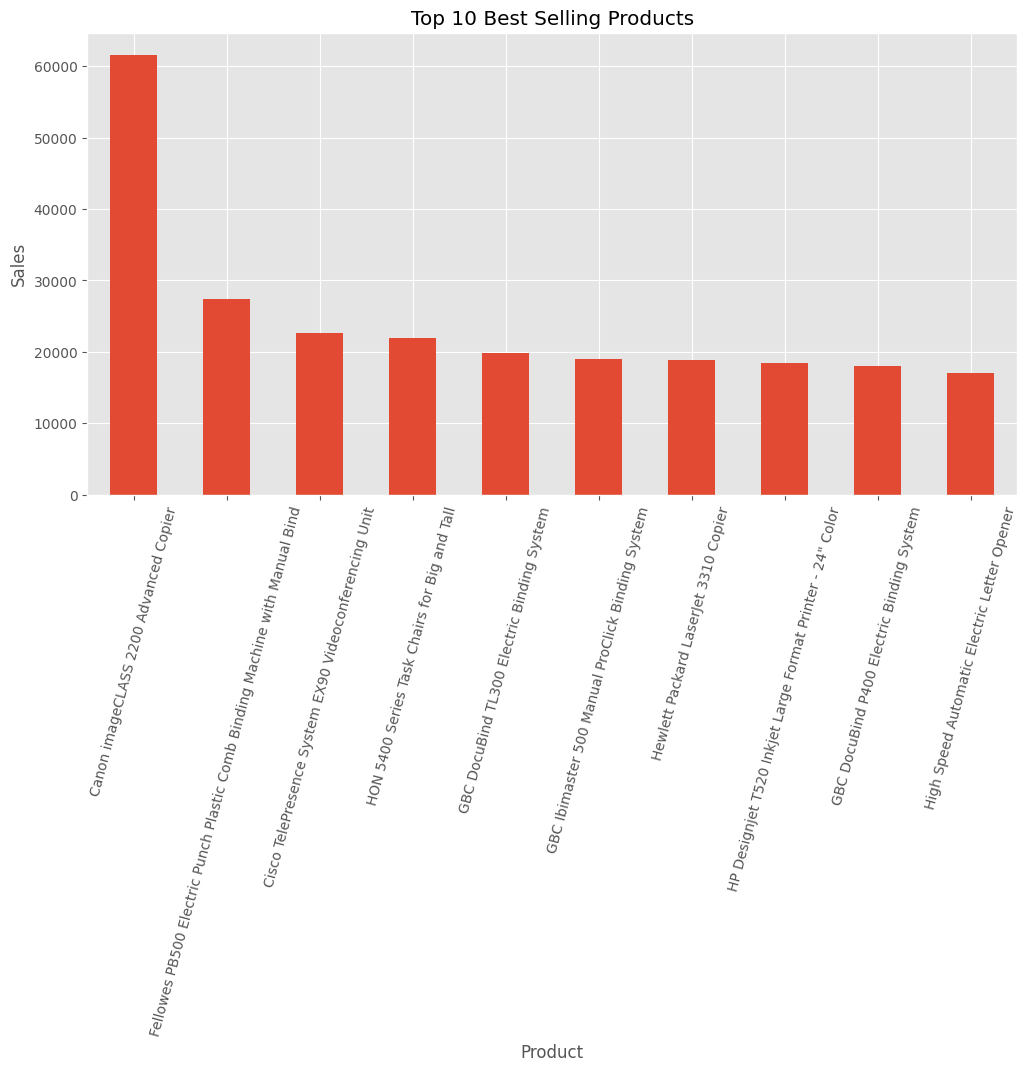

In [44]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Best Selling Products")

plt.xlabel("Product")

plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.show()

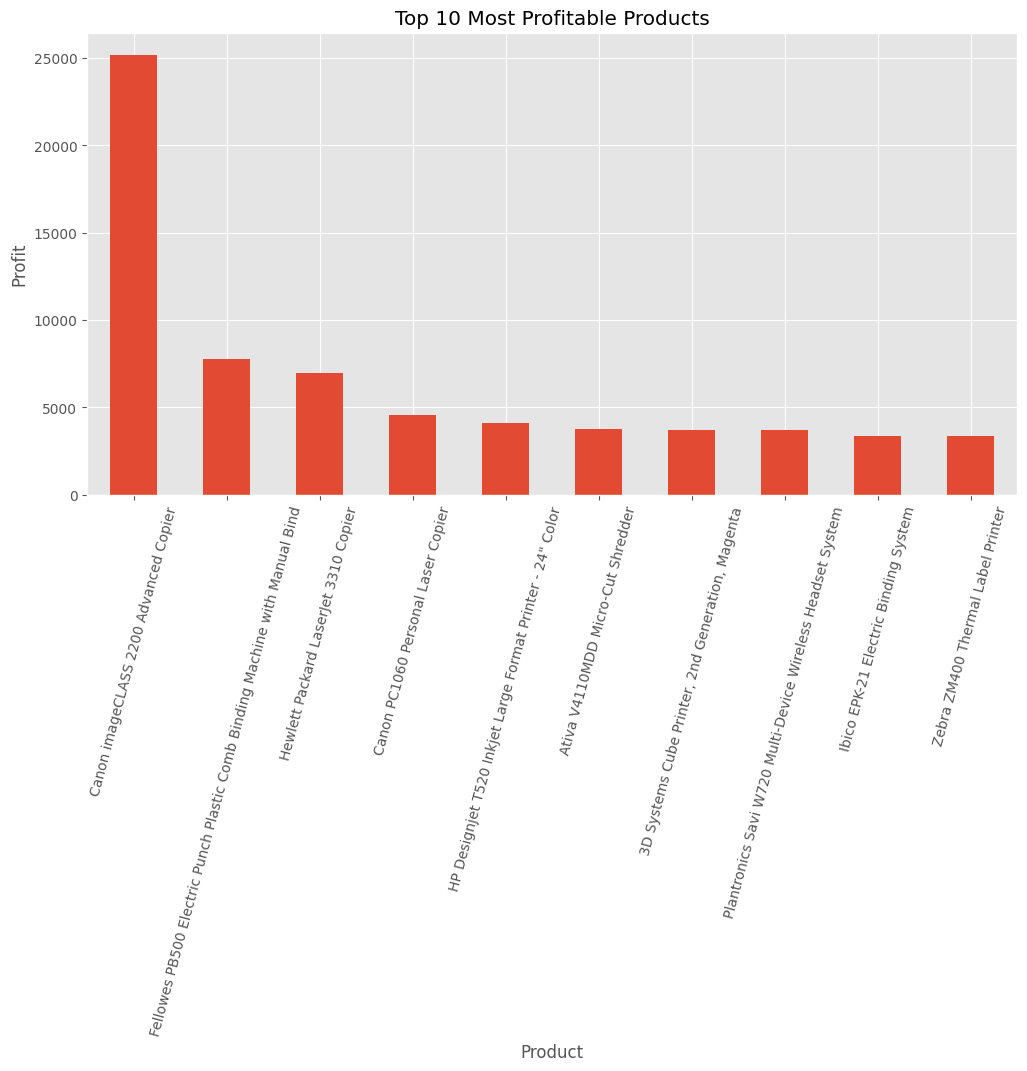

In [45]:
top_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_profit.plot(kind='bar')

plt.title("Top 10 Most Profitable Products")

plt.xlabel("Product")

plt.ylabel("Profit")

plt.xticks(rotation=75)

plt.show()

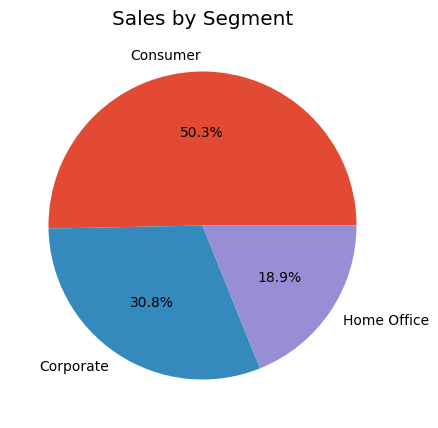

In [46]:
plt.figure(figsize=(8,5))

df.groupby('Segment')['Sales'].sum().plot(kind='pie',autopct='%1.1f%%')

plt.title("Sales by Segment")

plt.ylabel("")

plt.show()

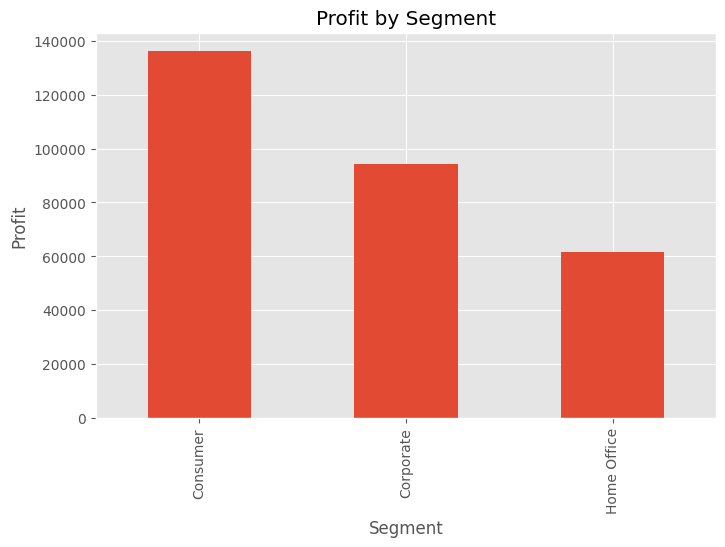

In [47]:
plt.figure(figsize=(8,5))

df.groupby('Segment')['Profit'].sum().plot(kind='bar')

plt.title("Profit by Segment")

plt.ylabel("Profit")

plt.show()

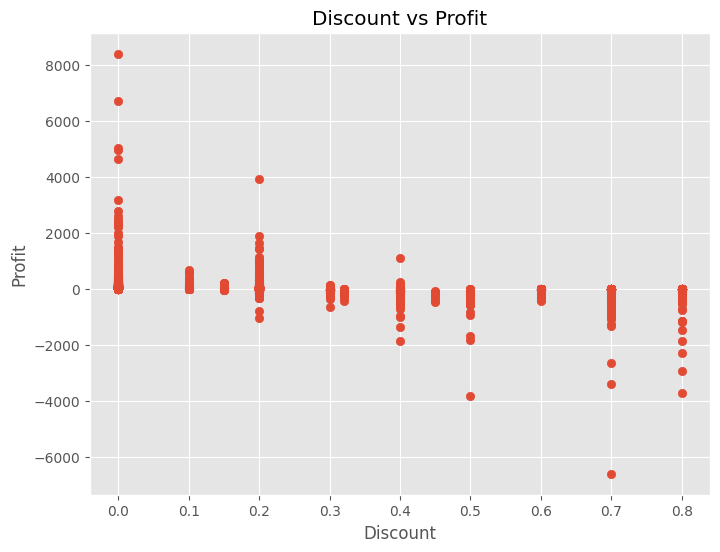

In [48]:
plt.figure(figsize=(8,6))

plt.scatter(df['Discount'],df['Profit'])

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

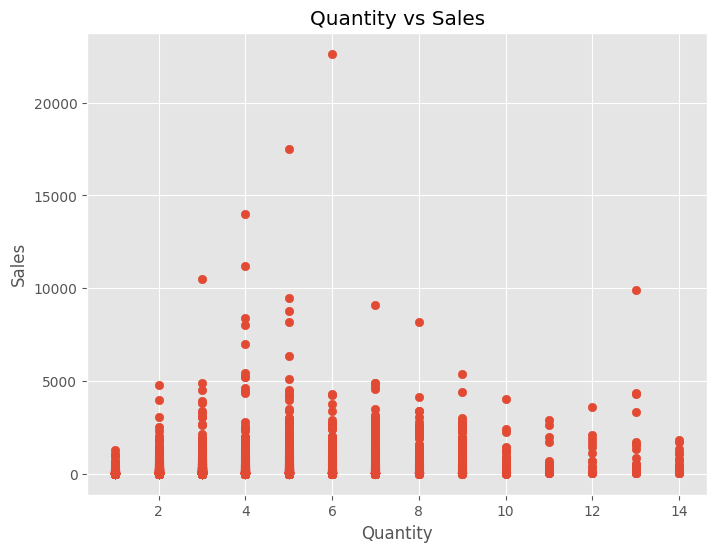

In [49]:
plt.figure(figsize=(8,6))

plt.scatter(df['Quantity'],df['Sales'])

plt.title("Quantity vs Sales")

plt.xlabel("Quantity")

plt.ylabel("Sales")

plt.show()

In [50]:
recommendations = [
"Increase focus on Technology products.",
"Maintain strong sales performance in the West region.",
"Reduce excessive discount strategies.",
"Promote top-performing products.",
"Develop marketing strategies for lower-performing regions.",
"Improve profitability in Furniture category."
]

print("Business Recommendations\n")

for i,r in enumerate(recommendations,1):
    print(f"{i}. {r}")

Business Recommendations

1. Increase focus on Technology products.
2. Maintain strong sales performance in the West region.
3. Reduce excessive discount strategies.
4. Promote top-performing products.
5. Develop marketing strategies for lower-performing regions.
6. Improve profitability in Furniture category.


In [51]:
print("="*70)
print("        RETAIL BUSINESS PERFORMANCE ANALYSIS")
print("="*70)

print("\nDataset Shape :", df.shape)

print("\nTotal Sales : ${:,.2f}".format(df['Sales'].sum()))

print("Total Profit : ${:,.2f}".format(df['Profit'].sum()))

print("Average Sales : ${:,.2f}".format(df['Sales'].mean()))

print("Average Profit : ${:,.2f}".format(df['Profit'].mean()))

print("\nHighest Sales Region :",
      df.groupby('Region')['Sales'].sum().idxmax())

print("Highest Sales Category :",
      df.groupby('Category')['Sales'].sum().idxmax())

print("Most Profitable Category :",
      df.groupby('Category')['Profit'].sum().idxmax())

print("="*70)

        RETAIL BUSINESS PERFORMANCE ANALYSIS

Dataset Shape : (10194, 25)

Total Sales : $2,326,534.35
Total Profit : $292,296.81
Average Sales : $228.23
Average Profit : $28.67

Highest Sales Region : West
Highest Sales Category : Technology
Most Profitable Category : Technology


In [52]:
insights = [

"Technology is the highest revenue generating category.",

"Consumer segment contributes nearly half of total sales.",

"West region achieved the highest overall sales.",

"Higher discounts often reduce profitability.",

"Furniture sales are high but profit margin remains relatively low."

]

print("\nPROJECT INSIGHTS\n")

for i,item in enumerate(insights,1):
    print(f"{i}. {item}")


PROJECT INSIGHTS

1. Technology is the highest revenue generating category.
2. Consumer segment contributes nearly half of total sales.
3. West region achieved the highest overall sales.
4. Higher discounts often reduce profitability.
5. Furniture sales are high but profit margin remains relatively low.


In [53]:
df.to_csv("Retail_Business_Cleaned.csv",index=False)

print("Dataset Saved Successfully.")

Dataset Saved Successfully.


In [54]:
print("""
Project Completed Successfully.

Files Generated

✔ Retail_Business_Cleaned.csv
✔ Google Colab Notebook
✔ Data Analysis
✔ Data Visualization
✔ Business Insights
✔ Recommendations
""")


Project Completed Successfully.

Files Generated

✔ Retail_Business_Cleaned.csv
✔ Google Colab Notebook
✔ Data Analysis
✔ Data Visualization
✔ Business Insights
✔ Recommendations

